# Background


![Schematic of measurement setup 1](figures\setup_1.png)

From a non-degenerate squeezed light source (SQZ) we recombine the field with the local oscillator (LO) with an FFR and get new outputs. We define the photocurrents measured in the photodetectors as:
\begin{align}
    \hat{\mathcal{I}}_1= \eta_{PD_1} e \hat E_1'^{(-)} \hat E_1'^{(+)} = \eta_{PD_1} e \hat A_1'^\dagger(t) \hat A_1'(t), && \hat{\mathcal{I}}_2 = \eta_{PD_2} e \hat A_2'^\dagger(t) \hat A_2'(t)
\end{align}
where a field is defined as $\hat E(t) = e^{-i\omega_0 t} \hat A(t) + h.c. = \hat E^{(+)} + \hat E^{(-)}$. We also define the difference (-) and combination (+) photocurrents (signals) as:
\begin{align}
    \hat{\mathcal{I}}_- = \hat{\mathcal{I}}_1 - \hat{\mathcal{I}}_2,
    && \hat{\mathcal{I}}_+ = \hat{\mathcal{I}}_1 + \hat{\mathcal{I}}_2
\end{align}


The following parameters are relevant for results:
| Parameter | Meaning |
|-----------|-------|
| $η_{PD_1}$    | Quantum efficiency of $PD_1$     |
| $η_{PD_2}$    | Quantum efficiency of $PD_2$     |
| $η_{FC_1}$    | Transmissivity of $FC_1$         |
| $η_{FC_2}$    | Transmissivity of $FC_2$         |
| $\alpha$      | LO coherent amplitude            |
| $\phi$        | LO phase                         |
| $r$           | Squeezing parameter              |
| $\theta$      | Squeezing angle                  |
| $\tau$        | Time delay of lower arm in FFR   |
| $\omega_0$    | Carrier (centre) frequency       |
| $B$           | PD measurement bandwith          |

The LO phase is added in the LO arm. We have that the FFR is the accumulation of the the arm path length distance and the refractive index of the fibers:
\begin{align}
    \tau = \frac{n \cdot \Delta L}{c}
\end{align}
In many formulas the $\zeta$ factors are used, these are given by:
\begin{align}
    \zeta_1 &= \sqrt{\eta_{FC_1} \eta_{FC_2}} \\
    \zeta_2 &= \sqrt{\eta_{FC_1} (1-\eta_{FC_2})} \\
    \zeta_3 &= \sqrt{(1-\eta_{FC_1}) \eta_{FC_2}} \\
    \zeta_4 &= \sqrt{(1-\eta_{FC_1}) (1-\eta_{FC_2})}
\end{align}

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from formulas.setup_1 import (
    expt_I_1, expt_I_2, expt_I_diff, expt_I_comb,
    var_I_1, var_I_2, var_I_diff, var_I_comb,
    cov_I_1_I_2,
)

## Constants

In [37]:
## Setup parameters

# Photodetectors
eta_PD_1 = 0.99
eta_PD_2 = 0.99

# Transissivities
eta_FC1 = 0.5
eta_FC2 = 0.5

# LO
alpha = 1
phi = 0

# Squeezing
r = 1
theta = 0

# Frequencies
omega_0 = 1
B = 2

#Squeezing angle and FFR delay will be set as intervalls unique to separate plots.

In [38]:
## Natural constants
e = 1 #unit charge

## Individual signals

In [39]:
tau = np.linspace(0, 4 * np.pi / omega_0, 300)
a = (eta_FC1, eta_FC2, eta_PD_1, eta_PD_2, e, alpha, phi, r, theta, B, omega_0)

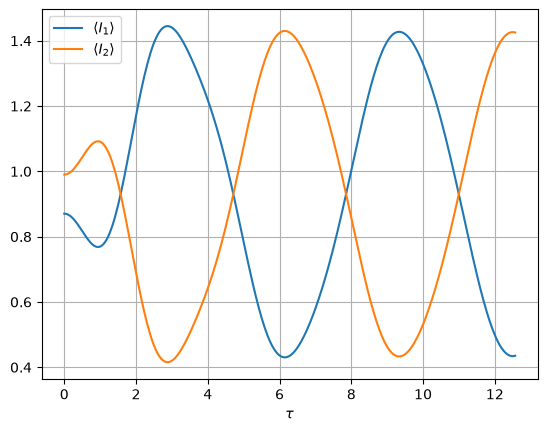

In [40]:
plt.plot(tau, [expt_I_1(*a, t) for t in tau], label=r"$\langle I_1\rangle$")
plt.plot(tau, [expt_I_2(*a, t) for t in tau], label=r"$\langle I_2\rangle$")
plt.xlabel(r"$\tau$"); plt.legend(); plt.grid(); plt.show()

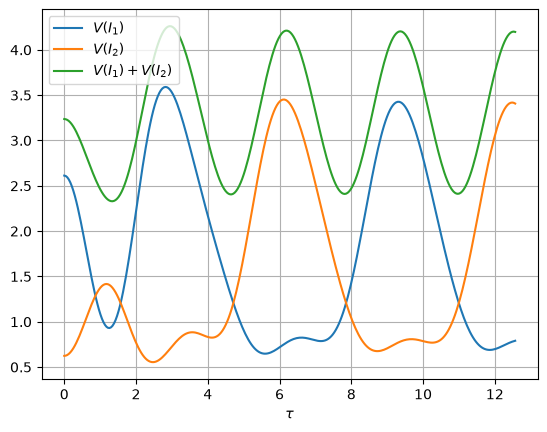

In [41]:
plt.plot(tau, [var_I_1(*a, t) for t in tau], label=r"$V(I_1)$")
plt.plot(tau, [var_I_2(*a, t) for t in tau], label=r"$V(I_2)$")
plt.plot(tau, [var_I_1(*a, t)+var_I_2(*a, t) for t in tau], label=r"$V(I_1)+V(I_2)$")
plt.xlabel(r"$\tau$"); plt.legend(); plt.grid(); plt.show()

## Difference and combination signals

In [42]:
tau = np.linspace(0, 4 * np.pi / omega_0, 300)
a = (eta_FC1, eta_FC2, eta_PD_1, eta_PD_2, e, alpha, phi, r, theta, B, omega_0)

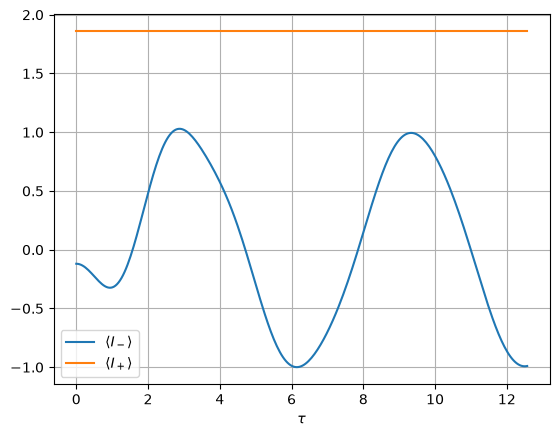

In [43]:
plt.plot(tau, [expt_I_diff(*a, t) for t in tau], label=r"$\langle I_-\rangle$")
plt.plot(tau, [expt_I_comb(*a, t) for t in tau], label=r"$\langle I_+\rangle$")
plt.xlabel(r"$\tau$"); plt.legend(); plt.grid(); plt.show()

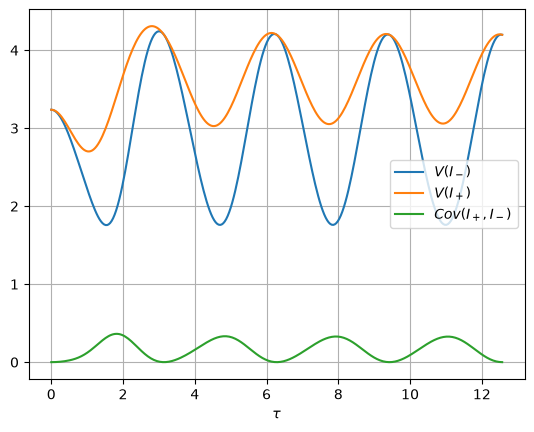

In [44]:
plt.plot(tau, [var_I_diff(*a, t) for t in tau], label=r"$V(I_-)$")
plt.plot(tau, [var_I_comb(*a, t) for t in tau], label=r"$V(I_+)$")
plt.plot(tau, [cov_I_1_I_2(*a, t) for t in tau], label=r"$Cov(I_+, I_-)$")
plt.xlabel(r"$\tau$"); plt.legend(); plt.grid();plt.show()